In [12]:
import pandas as pd
from Bio import SeqIO
from collections import Counter
from typing import List, Dict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def codon_usage_psite(csv_path: str, fasta_path: str, sample_col: str = "sample",
                      transcript_col: str = "transcript", psite_col: str = "psite") -> Dict[str, pd.DataFrame]:
    """
    Compute codon usage at P-sites from a CSV of reads and a transcript FASTA.

    Args:
        csv_path: Path to CSV file with columns [sample, transcript, psite]
        fasta_path: Path to transcript FASTA
        sample_col: Column in CSV indicating the sample name
        transcript_col: Column in CSV with transcript IDs
        psite_col: Column in CSV with P-site positions (1-based)
    
    Returns:
        A dict: {sample_name: DataFrame of codon counts/frequencies}
    """

    # --- Load CSV ---
    df = pd.read_csv(csv_path)
    # Ensure psite is integer
    df[psite_col] = df[psite_col].astype(int)

    # --- Load transcript sequences ---
    seq_dict = {record.id: str(record.seq) for record in SeqIO.parse(fasta_path, "fasta")}

    # --- Check transcripts ---
    bad_tx = df[transcript_col].unique()[~pd.Series(df[transcript_col].unique()).isin(seq_dict)]
    if len(bad_tx) > 0:
        print(f"Warning: {len(bad_tx)} transcripts missing in FASTA. First 10: {bad_tx[:10]}")

    # --- Function to extract codon at psite ---
    def get_codon(row):
        tx_seq = seq_dict.get(row[transcript_col])
        if not tx_seq:
            return None
        start = row[psite_col] - 1  # convert 1-based to 0-based
        end = start + 3
        if end > len(tx_seq):
            return None
        return tx_seq[start:end]

    df['p_site_codon'] = df.apply(get_codon, axis=1)

    # Drop missing codons
    df = df.dropna(subset=['p_site_codon'])

    # --- Compute codon usage per sample ---
    codon_usage = {}
    for sample, group in df.groupby(sample_col):
        codon_counts = Counter(group['p_site_codon'])
        total = sum(codon_counts.values())
        codon_freq = {codon: count / total for codon, count in codon_counts.items()}
        codon_usage[sample] = pd.DataFrame.from_dict(
            codon_freq, orient='index', columns=['frequency']
        ).sort_index()

    return codon_usage


In [ ]:
import pandas as pd
from Bio import SeqIO
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load reads psite CSV ---
df = pd.read_csv("reads_psite_list_th_all.csv")

# Ensure psite is integer
df['psite'] = df['psite'].astype(int)

# --- Load transcript FASTA ---
fasta_path = "gencode.vM35.transcripts.clean.fa"
seq_dict = {record.id: str(record.seq) for record in SeqIO.parse(fasta_path, "fasta")}

# --- Extract codon at P-site ---
def get_codon(row):
    tx_seq = seq_dict.get(row['transcript'])
    if not tx_seq:
        return None
    start = row['psite'] - 1  # 1-based to 0-based
    end = start + 3
    if end > len(tx_seq):
        return None
    return tx_seq[start:end]

df['p_site_codon'] = df.apply(get_codon, axis=1)
df = df.dropna(subset=['p_site_codon'])

# --- Compute codon usage per sample ---
codon_usage = {}
for sample, group in df.groupby('sample'):
    codon_counts = Counter(group['p_site_codon'])
    total = sum(codon_counts.values())
    codon_freq = {codon: count / total for codon, count in codon_counts.items()}
    codon_usage[sample] = pd.DataFrame.from_dict(
        codon_freq, orient='index', columns=['frequency']
    ).sort_index()

# --- Example: Combine into one DataFrame for plotting ---
plot_df = pd.concat([df.assign(sample=sample) for sample, df in codon_usage.items()])
plot_df = plot_df.reset_index().rename(columns={'index': 'codon'})

# --- Barplot: codon usage per sample ---
plt.figure(figsize=(16,5))
sns.barplot(x='codon', y='frequency', hue='sample', data=plot_df)
plt.xticks(rotation=90)
plt.title("Codon usage at P-sites per sample")
plt.show()


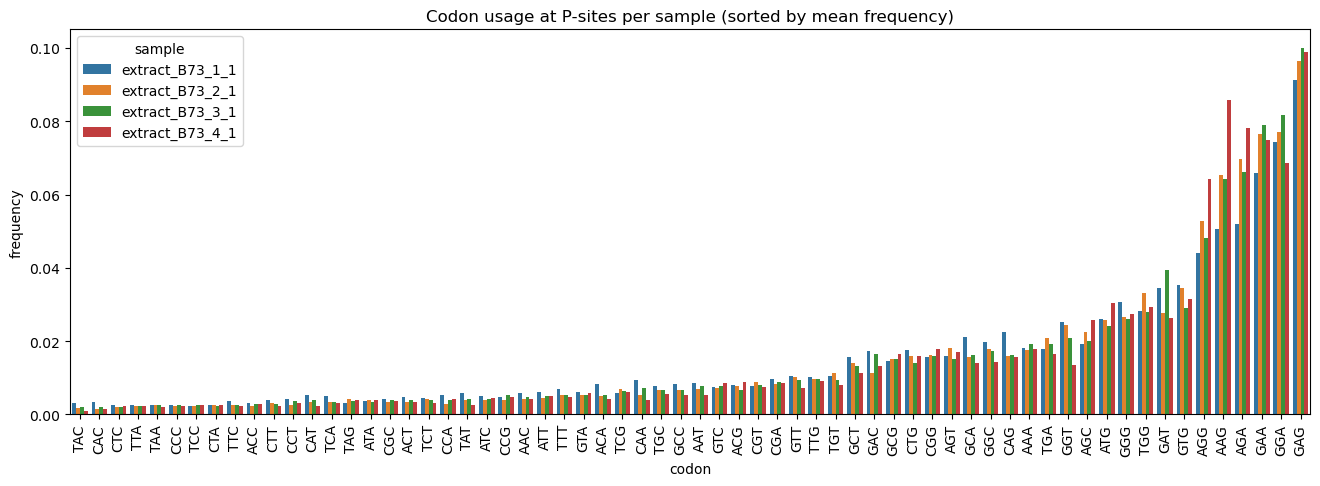

In [16]:
# Combine codon usage into a single DataFrame
plot_df = pd.concat([df.assign(sample=sample) for sample, df in codon_usage.items()])
plot_df = plot_df.reset_index().rename(columns={'index': 'codon'})

# Compute mean frequency across samples for sorting
codon_order = plot_df.groupby('codon')['frequency'].mean().sort_values().index

# Barplot sorted from least to most used codon
plt.figure(figsize=(16,5))
sns.barplot(x='codon', y='frequency', hue='sample', data=plot_df, order=codon_order)
plt.xticks(rotation=90)
plt.title("Codon usage at P-sites per sample (sorted by mean frequency)")
plt.savefig('codon_usaeg_all4samples.svg', dpi=300, bbox_inches='tight')
plt.show()


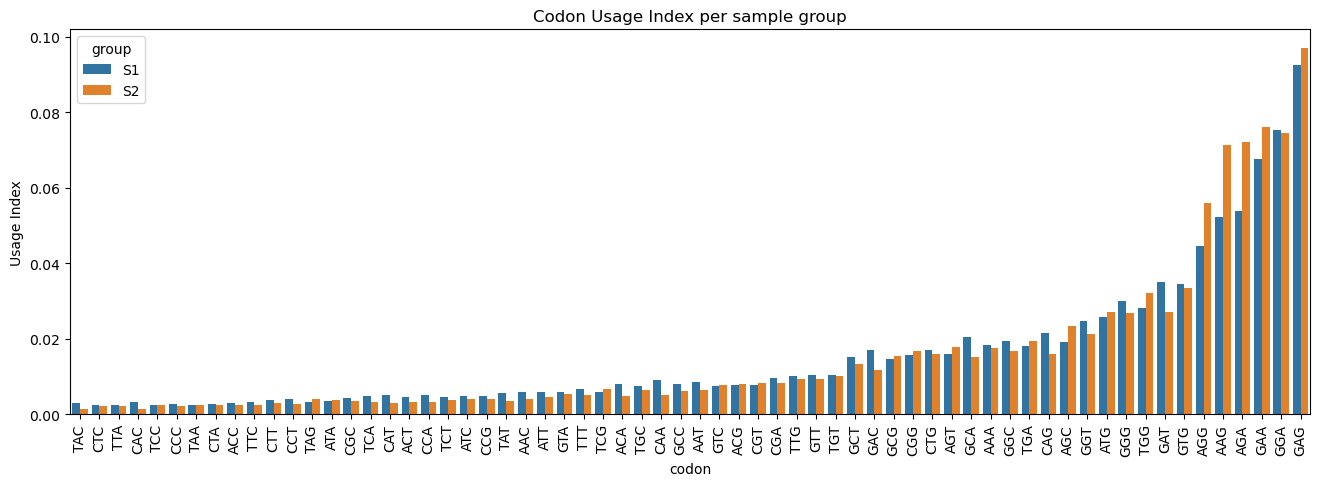

In [8]:
import pandas as pd
from Bio import SeqIO
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parameters ---
input_samples = {
    "S1": ["extract_B73_1_1", "extract_B73_3_1"],
    "S2": ["extract_B73_2_1", "extract_B73_4_1"]
}
contrast_samples = ["S1", "S2"]
csv_path = "reads_psite_list_th_all.csv"
fasta_path = "gencode.vM35.transcripts.clean.fa"

# --- Load reads psite CSV ---
df = pd.read_csv(csv_path)
df['psite'] = df['psite'].astype(int)

# --- Load transcript FASTA ---
seq_dict = {record.id: str(record.seq) for record in SeqIO.parse(fasta_path, "fasta")}

# --- Function to extract codon at P-site ---
def get_codon(row):
    tx_seq = seq_dict.get(row['transcript'])
    if not tx_seq:
        return None
    start = row['psite'] - 1  # convert 1-based to 0-based
    end = start + 3
    if end > len(tx_seq):
        return None
    return tx_seq[start:end]

# --- Compute codon usage index per sample group ---
codon_usage_index = {}

for group_name, samples in input_samples.items():
    # Subset rows for these samples
    df_group = df[df['sample'].isin(samples)].copy()
    df_group['p_site_codon'] = df_group.apply(get_codon, axis=1)
    df_group = df_group.dropna(subset=['p_site_codon'])
    
    # Count codons and compute usage index (fraction of total)
    codon_counts = Counter(df_group['p_site_codon'])
    total = sum(codon_counts.values())
    usage_index = {codon: count / total for codon, count in codon_counts.items()}
    
    codon_usage_index[group_name] = pd.DataFrame.from_dict(
        usage_index, orient='index', columns=['usage_index']
    ).reset_index().rename(columns={'index': 'codon'})

# --- Combine for plotting ---
plot_df = pd.concat([df.assign(group=group) for group, df in codon_usage_index.items()])
plot_df = plot_df.reset_index(drop=True)

# Sort codons by mean usage index across all groups
codon_order = plot_df.groupby('codon')['usage_index'].mean().sort_values().index

# --- Plot ---
plt.figure(figsize=(16,5))
sns.barplot(x='codon', y='usage_index', hue='group', data=plot_df, order=codon_order)
plt.xticks(rotation=90)
plt.ylabel("Usage Index")
plt.title("Codon Usage Index per sample group")
plt.show()


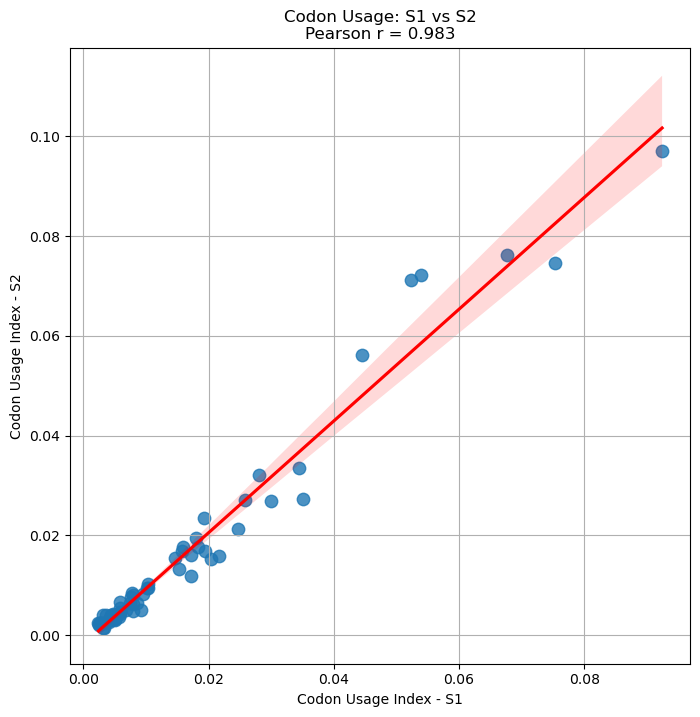

In [9]:
import pandas as pd
from Bio import SeqIO
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr



# --- Parameters ---
input_samples = {
    "S1": ["extract_B73_1_1", "extract_B73_3_1"],
    "S2": ["extract_B73_2_1", "extract_B73_4_1"]
}
contrast_samples = ["S1", "S2"]
csv_path = "reads_psite_list_th_all.csv"
fasta_path = "gencode.vM35.transcripts.clean.fa"

# --- Load reads psite CSV ---
df = pd.read_csv(csv_path)
df['psite'] = df['psite'].astype(int)

# --- Load transcript FASTA ---
seq_dict = {record.id: str(record.seq) for record in SeqIO.parse(fasta_path, "fasta")}

# --- Function to extract codon at P-site ---
def get_codon(row):
    tx_seq = seq_dict.get(row['transcript'])
    if not tx_seq:
        return None
    start = row['psite'] - 1  # 1-based → 0-based
    end = start + 3
    if end > len(tx_seq):
        return None
    return tx_seq[start:end]

# --- Compute usage index for each group ---
codon_usage_index = {}

for group_name, samples in input_samples.items():
    df_group = df[df['sample'].isin(samples)].copy()
    df_group['p_site_codon'] = df_group.apply(get_codon, axis=1)
    df_group = df_group.dropna(subset=['p_site_codon'])
    
    codon_counts = Counter(df_group['p_site_codon'])
    total = sum(codon_counts.values())
    usage_index = {codon: count / total for codon, count in codon_counts.items()}
    
    codon_usage_index[group_name] = pd.Series(usage_index, name=group_name)

# --- Combine two groups into one DataFrame for scatter plot ---
usage_df = pd.concat([codon_usage_index["S1"], codon_usage_index["S2"]], axis=1).fillna(0)

# --- Compute Pearson correlation ---
r, p_value = pearsonr(usage_df["S1"], usage_df["S2"])

# --- Plot scatter with regression line ---
plt.figure(figsize=(8,8))
sns.regplot(x="S1", y="S2", data=usage_df, ci=95, scatter_kws={'s':80}, line_kws={'color':'red'})
plt.xlabel("Codon Usage Index - S1")
plt.ylabel("Codon Usage Index - S2")
plt.title(f"Codon Usage: S1 vs S2\nPearson r = {r:.3f}")
plt.grid(True)
plt.show()

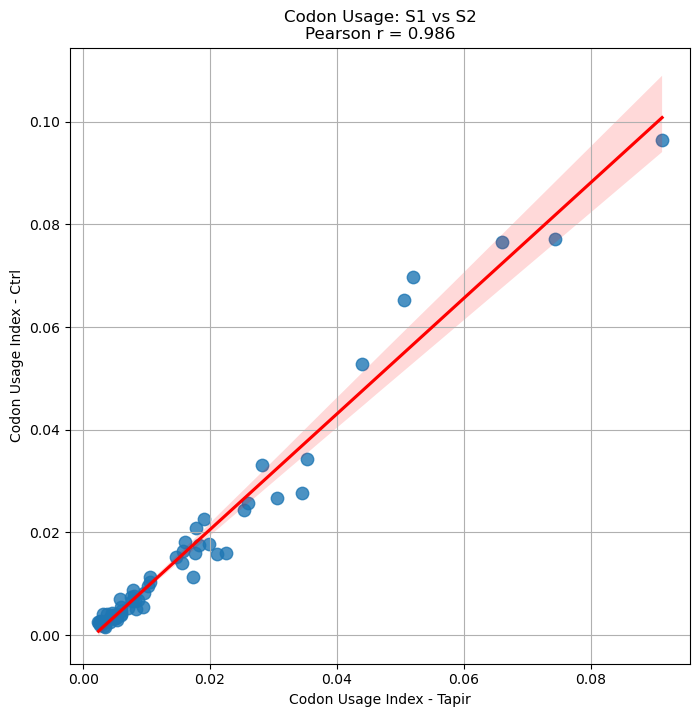

In [11]:
import pandas as pd
from Bio import SeqIO
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr



# --- Parameters ---
input_samples = {
    "Tapir": ["extract_B73_1_1" ],
    "Ctrl": ["extract_B73_2_1"]
}
contrast_samples = ["Tapir", "Ctrl"]
csv_path = "reads_psite_list_th_all.csv"
fasta_path = "gencode.vM35.transcripts.clean.fa"

# --- Load reads psite CSV ---
df = pd.read_csv(csv_path)
df['psite'] = df['psite'].astype(int)

# --- Load transcript FASTA ---
seq_dict = {record.id: str(record.seq) for record in SeqIO.parse(fasta_path, "fasta")}

# --- Function to extract codon at P-site ---
def get_codon(row):
    tx_seq = seq_dict.get(row['transcript'])
    if not tx_seq:
        return None
    start = row['psite'] - 1  # 1-based → 0-based
    end = start + 3
    if end > len(tx_seq):
        return None
    return tx_seq[start:end]

# --- Compute usage index for each group ---
codon_usage_index = {}

for group_name, samples in input_samples.items():
    df_group = df[df['sample'].isin(samples)].copy()
    df_group['p_site_codon'] = df_group.apply(get_codon, axis=1)
    df_group = df_group.dropna(subset=['p_site_codon'])
    
    codon_counts = Counter(df_group['p_site_codon'])
    total = sum(codon_counts.values())
    usage_index = {codon: count / total for codon, count in codon_counts.items()}
    
    codon_usage_index[group_name] = pd.Series(usage_index, name=group_name)

# --- Combine two groups into one DataFrame for scatter plot ---
usage_df = pd.concat([codon_usage_index["Tapir"], codon_usage_index["Ctrl"]], axis=1).fillna(0)

# --- Compute Pearson correlation ---
r, p_value = pearsonr(usage_df["Tapir"], usage_df["Ctrl"])

# --- Plot scatter with regression line ---
plt.figure(figsize=(8,8))
sns.regplot(x="Tapir", y="Ctrl", data=usage_df, ci=95, scatter_kws={'s':80}, line_kws={'color':'red'})
plt.xlabel("Codon Usage Index - Tapir")
plt.ylabel("Codon Usage Index - Ctrl")
plt.title(f"Codon Usage: S1 vs S2\nPearson r = {r:.3f}")
plt.grid(True)
plt.show()